<a href="https://colab.research.google.com/github/jsoook-dt/python-colab-analysis-study/blob/sook/project01_sook_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import kagglehub

# 1. Download the latest version of the dataset
path = kagglehub.dataset_download("manishabhatt22/marketing-campaign-performance-dataset")
print("Dataset path:", path)

# 2. Load the CSV file into a DataFrame
# Combines the download path with the specific filename
df = pd.read_csv(f"{path}/marketing_campaign_dataset.csv")

# 3. Verify data loading (Check the first 5 rows)
print("Data Sample:")
display(df.head())

# 4. Check data types and structure (Crucial for marketing analysis)
print("\nData Information:")
df.info()

100%|██████████| 5.02M/5.02M [00:00<00:00, 105MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/manishabhatt22/marketing-campaign-performance-dataset/versions/1
Data Sample:


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes

**info() 확인 시**
1. dataType은 dataFrame
2. index = 0 to 20000 (2만개 행)
3. column은 16개
4. null 값 확인
5. dtype 확인
6. 변수 뜻 확인

In [ ]:
# 처리된 결측치 확인 - .isnull().sum()
# 각 컬럼별 결측치 개수 반환
# .isnull() == .isna() : 결측 값은 True 반환, 그 외에는 False 반환하며
#                        데이터프레임 내에 결측 값을 확인하기 위해 사용
df.isna().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


In [ ]:
import pandas as pd
import numpy as np

# 2) Data Cleaning (Pre-processing) / Type casting
df = df.copy()

# (1) Acquisition_Cost: "$16,174.00" -> 16174.00 (float)
#     object타입의 Acquisition_Cost컬럼을 float으로 타입 변환, 변환 실패 시 NaN 처리
df["Acquisition_Cost_num"] = pd.to_numeric(
    df["Acquisition_Cost"]
      .astype(str)
      .str.replace(r"[^0-9.\-]", "", regex=True),
    errors="coerce"
)

df[["Acquisition_Cost", "Acquisition_Cost_num"]].head(3)

,Acquisition_Cost,Acquisition_Cost_num
0,"$16,174.00",16174.0
1,"$11,566.00",11566.0
2,"$10,200.00",10200.0


In [ ]:
# (2) Date: object -> datetime
#     object타입의 Date컬럼을 datatime 타입으로 변환, 변환 실패 시 NaN 처리
df["Date_data"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df[["Date", "Date_data"]].head(3)

,Date,Date_data
0,2021-01-01,2021-01-01
1,2021-01-02,2021-01-02
2,2021-01-03,2021-01-03


In [ ]:
# (3) Duration: "30 days" -> 30 (int)
#     object타입의 Duration컬럼을 int타입으로 변환, 변환 실패 시 NaN 처리
duration_num_str = df["Duration"].astype(str).str.extract(r"(\d+)", expand=False)

df["Duration_days"] = (
    pd.to_numeric(duration_num_str, errors="coerce")
      .astype("Int64")
)

df[["Duration", "Duration_days"]].head(3)

,Duration,Duration_days
0,30 days,30
1,60 days,60
2,30 days,30


In [ ]:
# 전처리 결과 컬럼만 보기
cols = ["Date", "Date_data", "Acquisition_Cost", "Acquisition_Cost_num", "Duration", "Duration_days"]
df[cols].head(5)

# 결측치 체크
df[cols].head(5).assign(
    Date_failed=df["Date_data"].isna(),
    Cost_failed=df["Acquisition_Cost_num"].isna(),
    Duration_failed=df["Duration_days"].isna()
)


,Date,Date_data,Acquisition_Cost,Acquisition_Cost_num,Duration,Duration_days,Date_failed,Cost_failed,Duration_failed
0,2021-01-01,2021-01-01,"$16,174.00",16174.0,30 days,30,False,False,False
1,2021-01-02,2021-01-02,"$11,566.00",11566.0,60 days,60,False,False,False
2,2021-01-03,2021-01-03,"$10,200.00",10200.0,30 days,30,False,False,False
3,2021-01-04,2021-01-04,"$12,724.00",12724.0,60 days,60,False,False,False
4,2021-01-05,2021-01-05,"$16,452.00",16452.0,15 days,15,False,False,False


In [ ]:
# 3.EDA (Exploratory Data Analysis)

# (1) Use df.describe() for summary statistics and check for outliers
#     숫자형 컬럼 요약 통계
display(df.describe())

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score,Acquisition_Cost_num,Date_data,Duration_days
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000,200000.0
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710,12504.393040,2021-07-01 23:35:09.600000,37.503975
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000,5000.000000,2021-01-01 00:00:00,15.0
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000,8739.750000,2021-04-02 00:00:00,30.0
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000,12496.500000,2021-07-02 00:00:00,30.0
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000,16264.000000,2021-10-01 00:00:00,45.0
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000,20000.000000,2021-12-31 00:00:00,60.0
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581,4337.664545,NaN,16.74672


In [ ]:
# (선택) 모든 컬럼 요약 통계(범주형 포함)
display(df.describe(include="all"))

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Acquisition_Cost_num,Date_data,Duration_days
count,200000.000000,200000,200000,200000,200000,200000,200000.000000,200000,200000.000000,200000,200000,200000.000000,200000.000000,200000.000000,200000,200000,200000.000000,200000,200000.0
unique,NaN,5,5,5,4,6,NaN,15001,NaN,5,5,NaN,NaN,NaN,5,365,NaN,NaN,<NA>
top,NaN,TechCorp,Influencer,Men 18-24,30 days,Email,NaN,"$16,578.00",NaN,Miami,Mandarin,NaN,NaN,NaN,Foodies,2021-12-02,NaN,NaN,<NA>
freq,NaN,40237,40169,40258,50255,33599,NaN,32,NaN,40269,40255,NaN,NaN,NaN,40208,548,NaN,NaN,<NA>
mean,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080070,NaN,5.002438,NaN,NaN,549.772030,5507.301520,5.494710,NaN,NaN,12504.393040,2021-07-01 23:35:09.600000,37.503975
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2.000000,NaN,NaN,100.000000,1000.000000,1.000000,NaN,NaN,5000.000000,2021-01-01 00:00:00,15.0
25%,50000.750000,NaN,NaN,NaN,NaN,NaN,0.050000,NaN,3.500000,NaN,NaN,325.000000,3266.000000,3.000000,NaN,NaN,8739.750000,2021-04-02 00:00:00,30.0
50%,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080000,NaN,5.010000,NaN,NaN,550.000000,5517.500000,5.000000,NaN,NaN,12496.500000,2021-07-02 00:00:00,30.0
75%,150000.250000,NaN,NaN,NaN,NaN,NaN,0.120000,NaN,6.510000,NaN,NaN,775.000000,7753.000000,8.000000,NaN,NaN,16264.000000,2021-10-01 00:00:00,45.0
max,200000.000000,NaN,NaN,NaN,NaN,NaN,0.150000,NaN,8.000000,NaN,NaN,1000.000000,10000.000000,10.000000,NaN,NaN,20000.000000,2021-12-31 00:00:00,60.0


In [ ]:
from IPython.display import display, Markdown

# 채널별 ROI 랭킹
channel_roi_rank = (
    df.groupby("Channel_Used")["ROI"]
      .agg(
          campaigns="count",
          mean_roi="mean",
          median_roi="median",
          std_roi="std",
          min_roi="min",
          max_roi="max"
      )
      .sort_values("mean_roi", ascending=False)
      .reset_index()
)

# 소수점 보기 좋게
channel_roi_rank[["mean_roi","median_roi","std_roi","min_roi","max_roi"]] = (
    channel_roi_rank[["mean_roi","median_roi","std_roi","min_roi","max_roi"]].round(3)
)
display(Markdown("## 채널별 ROI 랭킹표 (Mean ROI 기준)"))
display(channel_roi_rank)

## 채널별 ROI 랭킹표 (Mean ROI 기준)

,Channel_Used,campaigns,mean_roi,median_roi,std_roi,min_roi,max_roi
0,Facebook,32819,5.019,5.040,1.738,2.0,8.0
1,Website,33360,5.014,5.030,1.725,2.0,8.0
2,Google Ads,33438,5.003,5.010,1.734,2.0,8.0
3,Email,33599,4.996,5.000,1.738,2.0,8.0
4,YouTube,33392,4.994,4.970,1.732,2.0,8.0
5,Instagram,33392,4.989,4.985,1.739,2.0,8.0


In [ ]:
from IPython.display import display, Markdown

# 캠페인 타입별 전환율 랭킹
campaign_cvr_rank = (
    df.groupby("Campaign_Type")["Conversion_Rate"]
      .agg(
          campaigns="count",
          mean_cvr="mean",
          median_cvr="median",
          std_cvr="std",
          min_cvr="min",
          max_cvr="max"
      )
      .sort_values("mean_cvr", ascending=False)
      .reset_index()
)

# 보기 좋게 반올림
campaign_cvr_rank[["mean_cvr","median_cvr","std_cvr","min_cvr","max_cvr"]] = (
    campaign_cvr_rank[["mean_cvr","median_cvr","std_cvr","min_cvr","max_cvr"]].round(4)
)

display(Markdown("## 캠페인 타입별 전환율 랭킹표 (Mean CVR 기준)"))
display(campaign_cvr_rank)

## 캠페인 타입별 전환율 랭킹표 (Mean CVR 기준)

,Campaign_Type,campaigns,mean_cvr,median_cvr,std_cvr,min_cvr,max_cvr
0,Influencer,40169,0.0803,0.08,0.0405,0.01,0.15
1,Social Media,39817,0.0801,0.08,0.0405,0.01,0.15
2,Display,39987,0.0801,0.08,0.0408,0.01,0.15
3,Search,40157,0.0800,0.08,0.0405,0.01,0.15
4,Email,39870,0.0798,0.08,0.0407,0.01,0.15


In [ ]:
from IPython.display import display, Markdown

display(Markdown("## 📌 채널별 ROI vs 전환율(CVR) 균형 확인"))

# 1) 채널별 ROI 요약
ch_roi = (
    df.groupby("Channel_Used")["ROI"]
      .agg(roi_mean="mean", roi_median="median")
)

# 2) 채널별 CVR 요약
ch_cvr = (
    df.groupby("Channel_Used")["Conversion_Rate"]
      .agg(cvr_mean="mean", cvr_median="median")
)

# 3) 합치기
channel_balance = ch_roi.join(ch_cvr)

# 4) 랭킹(작을수록 좋음)
channel_balance["roi_rank"] = channel_balance["roi_mean"].rank(ascending=False, method="min").astype(int)
channel_balance["cvr_rank"] = channel_balance["cvr_mean"].rank(ascending=False, method="min").astype(int)

# 5) 균형 점수(둘 다 상위일수록 점수 낮음)
channel_balance["balance_score"] = channel_balance["roi_rank"] + channel_balance["cvr_rank"]

# 보기 좋게
channel_balance = channel_balance.sort_values("balance_score")
channel_balance = channel_balance.round(4)

display(channel_balance.reset_index())


## 📌 채널별 ROI vs 전환율(CVR) 균형 확인

,Channel_Used,roi_mean,roi_median,cvr_mean,cvr_median,roi_rank,cvr_rank,balance_score
0,Email,4.9965,5.000,0.0803,0.08,4,1,5
1,Facebook,5.0187,5.040,0.0800,0.08,1,4,5
2,Google Ads,5.0031,5.010,0.0802,0.08,3,2,5
3,Website,5.0142,5.030,0.0802,0.08,2,3,5
4,YouTube,4.9938,4.970,0.0799,0.08,5,5,10
5,Instagram,4.9887,4.985,0.0799,0.08,6,6,12


In [ ]:
from IPython.display import display, Markdown

display(Markdown("## 📌 기간별 ROI 비교 (15/30/45/60일)"))

target = [15, 30, 45, 60]

duration_roi_table = (
    df[df["Duration_days"].isin(target)]
      .groupby("Duration_days")["ROI"]
      .agg(campaigns="count", mean_roi="mean", median_roi="median")
      .sort_values("mean_roi", ascending=False)
      .round(3)
      .reset_index()
)

display(duration_roi_table)

best = int(duration_roi_table.loc[0, "Duration_days"])
best_mean = float(duration_roi_table.loc[0, "mean_roi"])
print(f"✅ 평균 ROI 기준 최적 기간: {best}일 (mean ROI={best_mean})")


## 📌 기간별 ROI 비교 (15/30/45/60일)

,Duration_days,campaigns,mean_roi,median_roi
0,30,50255,5.009,5.02
1,60,49866,5.006,5.02
2,45,50100,4.998,5.00
3,15,49779,4.997,5.00


✅ 평균 ROI 기준 최적 기간: 30일 (mean ROI=5.009)


# 📌 전환율(CVR) 랭킹표 수치 읽는 법 (필기용)

---

## 1) 평균(mean) 보는 법
- `mean_cvr = 0.0803` → **8.03%**
- 비교는 **%p(퍼센트포인트)**로 보기  
  - 예: `0.0803 - 0.0798 = 0.0005` → **0.05%p**
- **0.05%p 수준 차이는**(표본이 비슷할 때) 실무에서 **거의 차이 없는 경우가 많음**

---

## 2) 중앙값(median) 보는 법
- `median_cvr`가 `mean_cvr`와 비슷하면 → **전형적인 성과도 비슷**
- `median`이 다 같은데 `mean`만 조금 다르면 → **일부 극단값(꼬리)이 평균을 끌었을 가능성**

---

## 3) 표준편차(std) 보는 법 (변동성/안정성)
- `std` = **흔들림(변동성) 크기**
- 핵심은 **mean 대비 std 비율**
  - `std ≥ mean의 절반` → 변동성 **꽤 큰 편**
  - `std ≫ mean` → 평균만 믿기 위험(케이스 편차 큼)

### ✅ 캠페인 내 예시
- `mean ≈ 0.08`, `std ≈ 0.0405`  
→ std가 mean의 **약 50%** → 전환율이 **꽤 들쑥날쑥**(캠페인별 편차 존재)

---

## 4) min / max 보는 법
- 예: `min=0.01`, `max=0.15` → **최저 1%, 최고 15%**
- 의미: **대박/폭망 범위가 넓다**는 참고 신호

---

# ✅ 핵심 포인트 (암기 6개)
1. 랭킹표는 **“1위”보다 “차이가 의미 있는가”**가 핵심  
   → mean만 보지 말고 **median, std** 같이 본다.
2. `campaigns(count)` = **표본 수**  
   → 작으면 평균이 흔들림(신뢰도 체크).
3. **mean vs median**  
   - mean: 극단값 영향 O  
   - median: 극단값 영향 ↓  
   → 둘이 다르면 **꼬리/극단값 영향** 가능성.
4. `std` = **변동성/안정성**  
   → std 크면 성과 들쑥날쑥(리스크↑).
5. 현재 결과 해석  
   - mean 차이 **0.05%p 수준** + median 동일 + std 유사  
   → **타입만으로 전환 성과를 크게 구분하기 어려움**
6. 다음 분석 방향  
   → 차이가 작으면 **조합(타입×채널×타겟/기간)**에서 갈림

## 📌 기간별 ROI 랭킹표 + 박스플롯 (15/30/45/60일)

,Duration_days,campaigns,mean_roi,median_roi,std_roi,min_roi,max_roi
0,30,50255,5.009,5.02,1.734,2.0,8.0
1,60,49866,5.006,5.02,1.737,2.0,8.0
2,45,50100,4.998,5.00,1.737,2.0,8.0
3,15,49779,4.997,5.00,1.730,2.0,8.0


<Figure size 700x500 with 0 Axes>

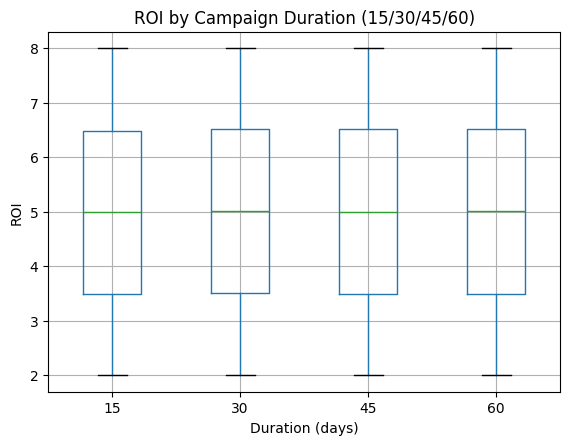

In [ ]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

#기간별 ROI 랭킹표 + 박스플롯
display(Markdown("## 📌 기간별 ROI 랭킹표 + 박스플롯 (15/30/45/60일)"))

# 1) 랭킹표 (15/30/45/60만)
target_durations = [15, 30, 45, 60]

duration_roi_rank = (
    df[df["Duration_days"].isin(target_durations)]
      .groupby("Duration_days")["ROI"]
      .agg(
          campaigns="count",
          mean_roi="mean",
          median_roi="median",
          std_roi="std",
          min_roi="min",
          max_roi="max"
      )
      .sort_values("mean_roi", ascending=False)
      .reset_index()
)

duration_roi_rank[["mean_roi","median_roi","std_roi","min_roi","max_roi"]] = (
    duration_roi_rank[["mean_roi","median_roi","std_roi","min_roi","max_roi"]].round(3)
)

display(duration_roi_rank)

# 2) 박스플롯
tmp = df[df["Duration_days"].isin(target_durations)][["Duration_days", "ROI"]].dropna()

plt.figure(figsize=(7,5))
tmp.boxplot(column="ROI", by="Duration_days")
plt.title("ROI by Campaign Duration (15/30/45/60)")
plt.suptitle("")
plt.xlabel("Duration (days)")
plt.ylabel("ROI")
plt.show()


In [ ]:
from IPython.display import display, Markdown

# 요약 딕셔너리(리포트 초안)
display(Markdown("## 📌 Sprint 1 Summary (Draft Report Dictionary)"))

# Top 1 값들 뽑기 (표가 비어있을 경우 대비)
top_channel = channel_roi_rank.loc[0, "Channel_Used"] if len(channel_roi_rank) else None
top_channel_mean_roi = float(channel_roi_rank.loc[0, "mean_roi"]) if len(channel_roi_rank) else None

top_campaign_type = campaign_cvr_rank.loc[0, "Campaign_Type"] if len(campaign_cvr_rank) else None
top_campaign_mean_cvr = float(campaign_cvr_rank.loc[0, "mean_cvr"]) if len(campaign_cvr_rank) else None

best_duration = int(duration_roi_rank.loc[0, "Duration_days"]) if len(duration_roi_rank) else None
best_duration_mean_roi = float(duration_roi_rank.loc[0, "mean_roi"]) if len(duration_roi_rank) else None

summary = {
    "Sprint": "Sprint 1 (Week 1-2)",
    "Dataset_rows": int(len(df)),
    "Top_ROI_Channel_by_mean": top_channel,
    "Top_ROI_Channel_mean_ROI": top_channel_mean_roi,
    "Top_Conversion_Campaign_Type_by_mean": top_campaign_type,
    "Top_Conversion_Campaign_Type_mean_CVR": top_campaign_mean_cvr,
    "Best_Duration_by_mean_ROI": best_duration,
    "Best_Duration_mean_ROI": best_duration_mean_roi,
    "Cost_ROI_Pearson_corr": float(corr) if "corr" in globals() and corr is not None else None
}

summary


## 📌 Sprint 1 Summary (Draft Report Dictionary)

{'Sprint': 'Sprint 1 (Week 1-2)',
 'Dataset_rows': 200000,
 'Top_ROI_Channel_by_mean': 'Facebook',
 'Top_ROI_Channel_mean_ROI': 5.019,
 'Top_Conversion_Campaign_Type_by_mean': 'Influencer',
 'Top_Conversion_Campaign_Type_mean_CVR': 0.0803,
 'Best_Duration_by_mean_ROI': 30,
 'Best_Duration_mean_ROI': 5.009,
 'Cost_ROI_Pearson_corr': 0.004584823490700822}

In [ ]:
from IPython.display import display, Markdown

display(Markdown("## 📝 Sprint 1 한글 리포트 초안 (자동 생성)"))

# 안전하게 Top 값들 추출
top_channel = channel_roi_rank.loc[0, "Channel_Used"] if len(channel_roi_rank) else "N/A"
top_channel_mean = channel_roi_rank.loc[0, "mean_roi"] if len(channel_roi_rank) else np.nan
top_channel_median = channel_roi_rank.loc[0, "median_roi"] if len(channel_roi_rank) else np.nan

top_type = campaign_cvr_rank.loc[0, "Campaign_Type"] if len(campaign_cvr_rank) else "N/A"
top_type_mean = campaign_cvr_rank.loc[0, "mean_cvr"] if len(campaign_cvr_rank) else np.nan
top_type_median = campaign_cvr_rank.loc[0, "median_cvr"] if len(campaign_cvr_rank) else np.nan

best_duration = duration_roi_rank.loc[0, "Duration_days"] if len(duration_roi_rank) else "N/A"
best_duration_mean = duration_roi_rank.loc[0, "mean_roi"] if len(duration_roi_rank) else np.nan
best_duration_median = duration_roi_rank.loc[0, "median_roi"] if len(duration_roi_rank) else np.nan

corr_val = corr if "corr" in globals() else np.nan

# 상관계수 해석 텍스트(간단 기준)
def corr_comment(x):
    if pd.isna(x):
        return "상관계수를 계산할 수 없습니다(결측/데이터 문제)."
    ax = abs(x)
    if ax < 0.1:
        return "상관이 매우 약해, 비용이 ROI를 선형적으로 설명한다고 보기 어렵습니다."
    elif ax < 0.3:
        return "약한 상관이 관찰되며, 비용과 ROI 사이에 약한 선형 경향이 있습니다."
    elif ax < 0.5:
        return "중간 정도 상관이 관찰되며, 비용과 ROI 사이의 선형 관계가 어느 정도 존재합니다."
    else:
        return "강한 상관이 관찰되며, 비용과 ROI 사이의 선형 관계가 뚜렷합니다."

corr_text = corr_comment(corr_val)

report_lines = [
    f"1) 채널 효율 분석 결과, 평균 ROI 기준으로 **{top_channel}** 채널이 가장 높았습니다 (평균 ROI={top_channel_mean:.3f}, 중앙값 ROI={top_channel_median:.3f}).",
    f"2) 전환 성과 분석 결과, 평균 전환율 기준으로 **{top_type}** 캠페인 타입이 가장 높았습니다 (평균 CVR={top_type_mean:.4f}, 중앙값 CVR={top_type_median:.4f}).",
    f"3) 획득비용(Acquisition Cost)과 ROI의 피어슨 상관계수는 **{corr_val:.4f}**로 나타났습니다. {corr_text}",
    f"4) 캠페인 기간(15/30/45/60일) 비교 결과, 평균 ROI 기준으로 **{best_duration}일** 캠페인이 가장 우수했습니다 (평균 ROI={best_duration_mean:.3f}, 중앙값 ROI={best_duration_median:.3f}).",
    "5) 종합하면, 현재 데이터에서는 **채널 선택/캠페인 타입/기간**이 성과 차이를 만드는 핵심 축이며, 비용 자체보다 **집행 조합(채널·타겟·기간)의 최적화** 관점에서 다음 스프린트 분석을 확장하는 것이 타당합니다."
]

# 출력
for line in report_lines:
    print(line)


## 📝 Sprint 1 한글 리포트 초안 (자동 생성)

1) 채널 효율 분석 결과, 평균 ROI 기준으로 **Facebook** 채널이 가장 높았습니다 (평균 ROI=5.019, 중앙값 ROI=5.040).
2) 전환 성과 분석 결과, 평균 전환율 기준으로 **Influencer** 캠페인 타입이 가장 높았습니다 (평균 CVR=0.0803, 중앙값 CVR=0.0800).
3) 획득비용(Acquisition Cost)과 ROI의 피어슨 상관계수는 **0.0046**로 나타났습니다. 상관이 매우 약해, 비용이 ROI를 선형적으로 설명한다고 보기 어렵습니다.
4) 캠페인 기간(15/30/45/60일) 비교 결과, 평균 ROI 기준으로 **30일** 캠페인이 가장 우수했습니다 (평균 ROI=5.009, 중앙값 ROI=5.020).
5) 종합하면, 현재 데이터에서는 **채널 선택/캠페인 타입/기간**이 성과 차이를 만드는 핵심 축이며, 비용 자체보다 **집행 조합(채널·타겟·기간)의 최적화** 관점에서 다음 스프린트 분석을 확장하는 것이 타당합니다.
